# Relatório do Laboratório 2 — Extração de Características (*Features*)

### ESZA019 — Visão Computacional · UFABC · 2026.2

---

**Autores:**

| # | Nome completo | RA |
|---|---------------|----|
| 1 | *Antonio Carlos de Freitas Vidal Junior* | *11201920894* |
| 2 | *João Vitor De Oliveira Lamano* | *11202022114* |
| 3 | *Willian Kenji Takaracy* | *11201812251* |


## 1. Introdução

Neste segundo laboratório da disciplina de Visão Computacional, demos um passo
além da simples captura de imagens (assunto do Lab 1) e entramos no tema de
**extração de características** — em inglês, *feature detection and description*.
A ideia central é a seguinte: em vez de olhar para a imagem inteira como um
amontoado de pixels, o computador procura **pontos especiais** dentro dela (como
cantos e regiões bem marcantes) e descreve cada um desses pontos de um jeito que
permita reconhecê-lo mesmo que a imagem mude de tamanho, gire ou seja vista de
outro ângulo.

Esses pontos especiais são o que chamamos de *features* (características). Eles
funcionam como "marcos" da imagem: assim como uma pessoa reconhece um lugar pelos
seus pontos de referência, o computador reconhece e compara imagens olhando para
essas características. A partir delas é possível fazer tarefas muito úteis, como
**encontrar um objeto** dentro de uma cena, **juntar duas fotos** em um panorama
ou **estimar profundidade** usando duas câmeras.

O objetivo deste laboratório foi entender, na teoria e na prática, como detectar
e descrever características usando a biblioteca **OpenCV** em Python e, em
seguida, usá-las para **casar (*match*) pontos entre duas imagens** que contêm o
mesmo objeto. O relatório está organizado da seguinte forma: primeiro
apresentamos a **fundamentação teórica** dos principais detectores estudados
(Harris, Shi-Tomasi e SIFT) e da etapa de casamento de características; depois
descrevemos os **procedimentos experimentais** com os dois programas pedidos no
roteiro — o item (A), que casa duas imagens gravadas, e o item (B), que faz o
mesmo usando **duas webcams** ao mesmo tempo; por fim, trazemos a **análise e
discussão** dos resultados, com uma reflexão sobre como essas técnicas podem ser
aproveitadas no nosso trabalho final.


## 2. Fundamentação Teórica

### 2.1 O que são *features* (características)?

Antes de detectar qualquer coisa, vale entender **o que faz um ponto da imagem
ser uma boa característica**. Imagine que recortamos pequenos pedaços de uma
imagem e tentamos localizar de volta exatamente de onde cada pedaço veio:

- Um pedaço de uma **região lisa** (por exemplo, uma parede branca) é péssimo:
  ele se parece com vários outros lugares, então não dá para saber sua posição
  exata.
- Um pedaço em cima de uma **borda** (a fronteira entre duas regiões) é melhor,
  mas ainda é ambíguo: ele pode deslizar ao longo da borda sem que a aparência
  mude muito.
- Já um pedaço sobre um **canto** (onde duas bordas se encontram) é ótimo:
  qualquer deslocamento, em qualquer direção, muda bastante a sua aparência. Por
  isso o ponto fica bem "amarrado" e é fácil de localizar de novo.

Essa é a intuição por trás da maioria dos detectores: **bons pontos de interesse
costumam ser cantos** ou regiões com forte variação de intensidade em mais de uma
direção. Detectar a *feature* é encontrar **onde** esse ponto está; descrevê-la é
gerar um vetor de números (o **descritor**) que resume a vizinhança do ponto, de
forma que ele possa ser comparado com pontos de outras imagens.

### 2.2 Detector de cantos de Harris

O **detector de Harris** (Harris & Stephens, 1988) parte exatamente dessa ideia
de canto. Para cada pixel, ele analisa o quanto a aparência da vizinhança muda
quando deslocamos uma pequena janela em todas as direções. Esse comportamento é
resumido em uma matriz construída a partir das **derivadas (gradientes)** da
imagem nas direções *x* e *y*.

A partir dessa matriz, calcula-se um valor de resposta *R*. A interpretação é:

- *R* pequeno em módulo → região **lisa**;
- *R* negativo → **borda**;
- *R* grande e positivo → **canto** (é o que queremos).

Uma característica importante do Harris é que ele é **invariante à rotação**: se
girarmos a imagem, ele continua encontrando os mesmos cantos. Por outro lado, ele
**não é invariante à escala** — um canto visto de muito perto pode deixar de ser
detectado como canto quando a imagem é muito ampliada.

### 2.3 Detector de Shi-Tomasi (*Good Features to Track*)

O detector de **Shi-Tomasi** (Shi & Tomasi, 1994) é uma melhoria do Harris.
Em vez de usar a fórmula de resposta *R* original, ele observa diretamente os
dois **autovalores** da matriz de cada ponto e considera que há um canto quando
**o menor dos dois autovalores** é grande o suficiente. Na prática, esse critério
seleciona cantos mais estáveis e confiáveis, o que é especialmente útil quando
queremos **acompanhar (*track*)** esses pontos ao longo de um vídeo — daí o nome
do artigo, *Good Features to Track*. No OpenCV, esse detector está disponível na
função `cv.goodFeaturesToTrack`.

### 2.4 SIFT — *Scale-Invariant Feature Transform*

Tanto o Harris quanto o Shi-Tomasi sofrem com **mudanças de escala**. O **SIFT**
(Lowe, 2004) foi criado justamente para resolver esse problema e é o detector que
usamos nos experimentos. Ele entrega características que são robustas a
**mudança de escala, rotação e variações de iluminação**, o que o torna muito
poderoso para casar imagens tiradas em condições diferentes. De forma resumida, o
SIFT trabalha em quatro etapas:

1. **Detecção no espaço de escalas.** A imagem é suavizada (borrada) com filtros
   gaussianos de diferentes intensidades, formando várias versões em escalas
   distintas. A diferença entre versões vizinhas (a chamada *Diferença de
   Gaussianas*, ou DoG) destaca pontos que se sobressaem **independentemente da
   escala**.
2. **Localização dos pontos-chave (*keypoints*).** Entre os candidatos, descartam-se
   os pontos de baixo contraste e os que ficam sobre bordas, mantendo apenas os
   mais estáveis.
3. **Atribuição de orientação.** A cada ponto é atribuída uma orientação
   principal, calculada a partir dos gradientes da vizinhança. É isso que dá ao
   SIFT a sua **invariância à rotação**.
4. **Descritor.** Por fim, a região ao redor de cada ponto é resumida em um vetor
   de **128 números** que descreve a distribuição dos gradientes locais. É esse
   vetor que será comparado com os pontos de outra imagem.

No OpenCV, criamos o detector com `cv.SIFT_create()` e obtemos os pontos e seus
descritores de uma só vez com `sift.detectAndCompute(imagem, None)`.

### 2.5 Casamento de características e Homografia

Detectar e descrever os pontos é só metade do trabalho. Para **encontrar o mesmo
objeto em duas imagens**, precisamos **casar** os descritores de uma imagem com os
da outra. Os passos que aparecem no nosso código são:

- **Casamento por vizinhos mais próximos (FLANN + kNN).** Usamos o
  `cv.FlannBasedMatcher`, uma biblioteca otimizada para encontrar rapidamente os
  descritores mais parecidos. Para cada ponto da primeira imagem, pedimos os
  **dois** vizinhos mais próximos na segunda (`knnMatch(..., k=2)`).
- **Teste da razão de Lowe.** Nem todo casamento é confiável. O teste de Lowe
  guarda um par apenas quando o melhor vizinho é **bem mais próximo** que o
  segundo melhor (no código, quando `m.distance < 0.7 * n.distance`). Isso
  elimina a maior parte dos casamentos ambíguos e errados.
- **Homografia com RANSAC.** Tendo bons casamentos, calculamos uma **homografia**
  com `cv.findHomography(..., cv.RANSAC)`. A homografia é uma transformação que
  relaciona o plano do objeto na primeira imagem com a sua posição na segunda.
  O **RANSAC** torna esse cálculo robusto: ele ignora os poucos casamentos
  errados que sobraram (os *outliers*) e usa só os corretos (*inliers*).
  Com a homografia em mãos, transformamos os quatro cantos do objeto da primeira
  imagem (`cv.perspectiveTransform`) e **desenhamos um contorno** em volta dele na
  segunda imagem — foi assim que conseguimos "achar o objeto" na cena.

Esse encadeamento — **SIFT → FLANN/kNN → razão de Lowe → homografia/RANSAC** — é
exatamente o pipeline do tutorial *Feature Matching + Homography to find Objects*
do OpenCV, que serviu de base para o item (A) deste laboratório.


## 3. Procedimentos experimentais

Os experimentos foram realizados em um computador com **Linux**, usando um
**ambiente virtual** (Conda) já configurado com **Python** e **OpenCV**. O
roteiro pedia dois programas, que tratamos como os itens (A) e (B) a seguir:

- **(A)** Um programa que lê **duas imagens já gravadas** contendo o mesmo objeto
  em posições diferentes e faz o casamento SIFT com homografia, mostrando as
  correspondências e o objeto localizado.
- **(B)** Uma versão modificada que lê **duas webcams** pelo mesmo código,
  aplicando o mesmo casamento SIFT entre as duas imagens e mostrando o resultado
  em janela de vídeo a cada leitura.

As próximas seções trazem os códigos efetivamente usados (sem alterações) junto
com a explicação de cada etapa.


### 3.1 Item (A) — *Feature Matching + Homography* em imagens gravadas

Para este item, gravamos previamente duas imagens: uma é o **recorte de um
celular** (`celular_.png`, a *queryImage* — o objeto que queremos achar) e a
outra é uma **cena** em que uma pessoa segura esse mesmo celular
(`celular_cenario.png`, a *trainImage* — onde vamos procurar o objeto).

A célula abaixo carrega as imagens em tons de cinza, cria o detector **SIFT**,
extrai os pontos-chave e descritores de cada imagem e faz o casamento com o
**FLANN**, aplicando o **teste da razão de Lowe** para guardar só os bons pares.
Definimos `MIN_MATCH_COUNT = 10`, ou seja, exigimos pelo menos 10 bons casamentos
para considerar que o objeto foi encontrado.


In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

MIN_MATCH_COUNT = 10

img1 = cv.imread('celular_.png', cv.IMREAD_GRAYSCALE)          # queryImage
img2 = cv.imread('celular_cenario.png', cv.IMREAD_GRAYSCALE) # trainImage

# Initiate SIFT detector
sift = cv.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)

flann = cv.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1,des2,k=2)

# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)

Em seguida, com os bons casamentos em mãos, calculamos a **homografia** entre o
objeto e a cena usando o RANSAC. A partir dela, transformamos os quatro cantos do
recorte do celular e **desenhamos o contorno** do objeto localizado na imagem da
cena.


In [ ]:
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()

    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv.perspectiveTransform(pts,M)

    img2 = cv.polylines(img2,[np.int32(dst)],True,255,3, cv.LINE_AA)

else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None

Por fim, desenhamos as **linhas de correspondência** ligando cada ponto do
objeto ao ponto equivalente na cena (apenas os *inliers*, em verde) e exibimos o
resultado.


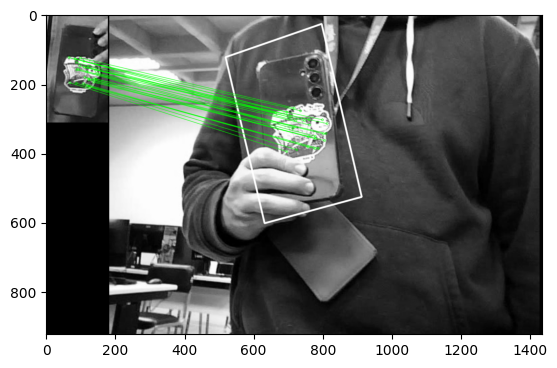

(<matplotlib.image.AxesImage at 0x75a2007c1bd0>, None)

In [ ]:
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

img3 = cv.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)

plt.imshow(img3, 'gray'),plt.show()

**Resultado do item (A).** Como mostra a figura acima, o programa funcionou bem:
o recorte do celular (à esquerda) foi **corretamente localizado** dentro da cena,
e o **contorno branco** desenhado pela homografia envolve exatamente o celular
que a pessoa segura. As **linhas verdes** ligam cada ponto-chave do objeto ao seu
correspondente na cena, e o fato de elas estarem praticamente paralelas e
concentradas na região certa indica que os casamentos foram consistentes. Mesmo
com o celular aparecendo em **escala e posição diferentes** na cena, o SIFT
conseguiu reconhecê-lo — o que confirma, na prática, a invariância a escala e
rotação discutida na teoria.


### 3.2 Item (B) — Casamento SIFT com duas webcams (câmera estéreo)

No item (B), modificamos o programa anterior para trabalhar com **duas webcams**
ligadas ao mesmo computador, montando uma espécie de **câmera estéreo** (uma
"esquerda" e uma "direita"). A ideia é capturar as duas imagens e aplicar o mesmo
casamento SIFT entre elas. Começamos importando as bibliotecas:


In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt


**Captura das duas câmeras.** O código abaixo abre as duas webcams
(`VideoCapture(0)` e `VideoCapture(1)`), mostra cada uma em sua própria janela e,
ao apertarmos a tecla **`x`**, salva um par de fotos (`foto_esquerda.png` e
`foto_direita.png`). A tecla **`q`** encerra sem salvar. Esse par de fotos é o que
será usado no casamento.


In [ ]:
# Lê 2 webcams e tira foto das duas quando apertamos a tecla 'x'
cap_esq = cv.VideoCapture(0)   # câmera esquerda
cap_dir = cv.VideoCapture(1)   # câmera direita

if not cap_esq.isOpened() or not cap_dir.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # captura um quadro de cada câmera
    ret_esq, frame_esq = cap_esq.read()
    ret_dir, frame_dir = cap_dir.read()
    # se alguma leitura falhou, ret é False
    if not ret_esq or not ret_dir:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # mostra cada quadro em sua própria janela
    cv.imshow('esquerda', frame_esq)
    cv.imshow('direita', frame_dir)

    key = cv.waitKey(1)          # lê a tecla apertada
    if key == ord('x'):          # 'x': salva as duas fotos e sai
        cv.imwrite('foto_esquerda.png', frame_esq)
        cv.imwrite('foto_direita.png', frame_dir)
        print("Fotos salvas como 'foto_esquerda.png' e 'foto_direita.png'!")
        break
    elif key == ord('q'):        # 'q': sai sem salvar
        break

cap_esq.release()
cap_dir.release()
cv.destroyAllWindows()

Com o par de fotos salvo, aplicamos **exatamente o mesmo pipeline do item (A)**
— SIFT, FLANN, razão de Lowe e homografia — agora entre a imagem da câmera
esquerda e a da câmera direita:


In [ ]:

MIN_MATCH_COUNT = 10

img1 = cv.imread('foto_esquerda.png', cv.IMREAD_GRAYSCALE)          # queryImage
img2 = cv.imread('foto_direita.png', cv.IMREAD_GRAYSCALE) # trainImage

# Initiate SIFT detector
sift = cv.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)

flann = cv.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1,des2,k=2)

# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)

In [ ]:
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()

    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv.perspectiveTransform(pts,M)

    img2 = cv.polylines(img2,[np.int32(dst)],True,255,3, cv.LINE_AA)

else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None

Not enough matches are found - 4/10


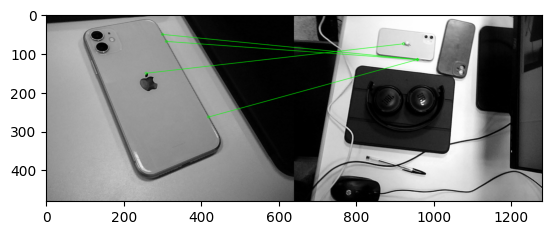

(<matplotlib.image.AxesImage at 0x7c75429f3750>, None)

In [ ]:
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

img3 = cv.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)

plt.imshow(img3, 'gray'),plt.show()

**Resultado do item (B) com fotos.** Aqui o resultado foi mais modesto do que no
item (A). Como o programa informou (`Not enough matches are found - 4/10`),
encontramos **apenas 4 bons casamentos**, abaixo dos 10 exigidos — por isso a
homografia **não foi calculada** e o contorno do objeto não aparece. Ainda assim,
o `drawMatches` mostra as poucas correspondências encontradas (linhas verdes
ligando o celular na imagem da esquerda ao da direita).

Esse comportamento faz sentido e é instrutivo: nas duas webcams, o objeto é visto
de **ângulos bastante diferentes** (a *baseline* entre as câmeras é grande) e com
**iluminação e fundo distintos**, o que reduz bastante o número de pontos que o
SIFT consegue casar com confiança. Discutimos isso melhor na Análise.


**Casamento SIFT em vídeo (tempo real).** Para atender ao pedido do roteiro de
mostrar o resultado **numa janela de vídeo a cada leitura das webcams**, fizemos
uma versão que roda o casamento SIFT **continuamente**, quadro a quadro, entre as
duas câmeras. Cada quadro do resultado mostra as duas imagens lado a lado com as
linhas de correspondência em verde e um contador com o número de *matches*. O
vídeo resultante é **gravado** no arquivo `saida_sift.avi`. A execução é encerrada
com a tecla **`q`**.


In [ ]:
# SIFT em vídeo com 2 webcams (câmera estéreo), gravando o resultado
cap_esq = cv.VideoCapture(0)   # câmera esquerda
cap_dir = cv.VideoCapture(1)   # câmera direita

if not cap_esq.isOpened() or not cap_dir.isOpened():
    print("Cannot open camera")
    exit()

# pega largura e altura de uma das câmeras
width  = int(cap_esq.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(cap_esq.get(cv.CAP_PROP_FRAME_HEIGHT))
fps = 30.0

# o drawMatches coloca as 2 imagens lado a lado -> o quadro de saída tem o DOBRO da largura
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('saida_sift.avi', fourcc, fps, (width * 2, height))

# prepara o detector SIFT e o matcher FLANN (uma vez só, fora do loop)
sift = cv.SIFT_create()
FLANN_INDEX_KDTREE = 1
index_params  = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

while cap_esq.isOpened() and cap_dir.isOpened():
    ret_esq, frame_esq = cap_esq.read()
    ret_dir, frame_dir = cap_dir.read()
    if not ret_esq or not ret_dir:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # converte para cinza (o SIFT trabalha em tons de cinza)
    gray_esq = cv.cvtColor(frame_esq, cv.COLOR_BGR2GRAY)
    gray_dir = cv.cvtColor(frame_dir, cv.COLOR_BGR2GRAY)

    # detecta keypoints e descritores em cada quadro
    kp1, des1 = sift.detectAndCompute(gray_esq, None)
    kp2, des2 = sift.detectAndCompute(gray_dir, None)

    # faz o casamento (só se houver descritores suficientes)
    good = []
    if des1 is not None and des2 is not None and len(kp1) > 2 and len(kp2) > 2:
        matches = flann.knnMatch(des1, des2, k=2)
        for par in matches:
            if len(par) == 2:              # garante que vieram os 2 vizinhos
                m, n = par
                if m.distance < 0.7 * n.distance:   # teste de razão de Lowe
                    good.append(m)

    # desenha os matches entre a câmera esquerda e a direita
    resultado = cv.drawMatches(
        frame_esq, kp1, frame_dir, kp2, good, None,
        matchColor=(0, 255, 0),
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # mostra o número de matches na tela
    cv.putText(resultado, f"Matches: {len(good)}", (10, 30),
               cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    out.write(resultado)            # grava o quadro no arquivo
    cv.imshow('SIFT estereo', resultado)
    if cv.waitKey(1) == ord('q'):
        break

cap_esq.release()
cap_dir.release()
out.release()
cv.destroyAllWindows()

> **Vídeo gerado:** o resultado em tempo real foi salvo como **`saida_sift.avi`**
> na pasta da equipe (publicado junto com este relatório no repositório do
> GitHub). Caso seja necessário hospedá-lo em algum lugar que não aceite `.avi`,
> o arquivo pode ser convertido para `.mp4`.


## 4. Análise e discussão

Os experimentos deixaram claro o **poder e também os limites** das técnicas de
extração de características. No item (A), com duas imagens preparadas de propósito
(um recorte limpo do objeto e uma cena bem iluminada), o SIFT brilhou: localizou o
celular mesmo em escala e posição diferentes, com casamentos abundantes e
consistentes. Já no item (B), o mesmo método entregou poucos casamentos. A
comparação entre os dois casos é o ponto mais rico do laboratório.

**Por que o item (B) deu menos *matches*?** Identificamos alguns motivos
principais:

- **Diferença de ponto de vista (*baseline*).** As duas webcams enxergam o objeto
  de ângulos bem distintos. Embora o SIFT seja robusto a escala e rotação no
  plano, mudanças grandes de **perspectiva 3D** alteram a aparência da vizinhança
  dos pontos e dificultam o casamento.
- **Iluminação e fundo diferentes** entre as duas câmeras, que mudam os gradientes
  locais usados pelo descritor.
- **Qualidade dos quadros das webcams** (foco, ruído, resolução), geralmente
  inferior à de imagens preparadas.

Isso sugere caminhos de melhoria que valeria testar: aproximar as câmeras (reduzir
a *baseline*), melhorar a iluminação, afrouxar um pouco o limiar da razão de Lowe
(por exemplo, de 0,7 para 0,75) ou reduzir o `MIN_MATCH_COUNT`. Vale notar ainda
que, num **par estéreo "bem comportado"**, o casamento de características é a base
para calcular **profundidade** — então o item (B) é, na verdade, a porta de
entrada para visão estéreo e reconstrução 3D.

### 4.1 Aplicações da detecção de *features* e uso no trabalho final

Pesquisando referências técnicas e científicas, vemos que o casamento de
características aparece em uma quantidade enorme de aplicações reais, entre elas:

- **Costura de imagens / panoramas (*image stitching*)**: alinhar e juntar várias
  fotos em uma imagem panorâmica usando homografia — exatamente a mesma matemática
  do nosso item (A).
- **Reconhecimento de objetos e Realidade Aumentada**: localizar um objeto ou
  marcador conhecido em uma cena para sobrepor informações.
- **Visão estéreo e reconstrução 3D**: casar pontos entre duas câmeras para
  estimar a profundidade da cena (extensão natural do nosso item B).
- **SLAM e navegação de robôs**: um robô ou drone usa *features* para se localizar
  e mapear o ambiente enquanto se move.
- **Registro de imagens (médicas e de satélite)**: alinhar imagens da mesma região
  tiradas em momentos ou por sensores diferentes.
- **Inspeção visual industrial / controle de qualidade**: localizar peças,
  conferir montagem e detectar defeitos em linhas de produção.

## 5. Conclusões

De forma geral, cumprimos os objetivos do laboratório. Estudamos a teoria por trás
da **detecção e descrição de características**, entendendo por que cantos são bons
pontos de interesse e comparando os detectores de **Harris**, **Shi-Tomasi** e
**SIFT** — sendo este último o mais robusto, por ser invariante a escala e
rotação.

Na prática, implementamos e executamos os dois programas pedidos:

1. No **item (A)**, casamos duas imagens gravadas do mesmo celular com SIFT, FLANN,
   o teste da razão de Lowe e a homografia com RANSAC, conseguindo **localizar
   corretamente o objeto** dentro da cena.
2. No **item (B)**, adaptamos o código para usar **duas webcams**, aplicando o
   mesmo casamento entre as imagens e gerando também um **vídeo** com o resultado
   em tempo real (`saida_sift.avi`).

Um aprendizado importante veio justamente da diferença entre os dois resultados: o
casamento de características é poderoso, mas **sensível às condições de captura**
(ângulo, iluminação e qualidade da imagem). O número baixo de *matches* no item
(B) não foi um "erro", e sim um resultado real que nos ajudou a entender os
limites do método e a pensar em melhorias. No conjunto, o laboratório deu uma base
sólida sobre *features* e abriu caminho para aplicações mais avançadas, como visão
estéreo, reconhecimento de objetos e inspeção visual.


## 6. Referências

1. LOWE, D. G. *Distinctive Image Features from Scale-Invariant Keypoints*.
   International Journal of Computer Vision, v. 60, n. 2, p. 91-110, 2004.
2. HARRIS, C.; STEPHENS, M. *A Combined Corner and Edge Detector*. Proceedings of
   the Alvey Vision Conference, p. 147-151, 1988.
3. SHI, J.; TOMASI, C. *Good Features to Track*. IEEE Conference on Computer
   Vision and Pattern Recognition (CVPR), p. 593-600, 1994.
4. FISCHLER, M. A.; BOLLES, R. C. *Random Sample Consensus (RANSAC)*.
   Communications of the ACM, v. 24, n. 6, p. 381-395, 1981.
5. MUJA, M.; LOWE, D. G. *Fast Approximate Nearest Neighbors with Automatic
   Algorithm Configuration (FLANN)*. VISAPP, 2009.
6. OpenCV — *Feature Detection and Description (Table of Contents)*.
   https://docs.opencv.org/4.x/db/d27/tutorial_py_table_of_contents_feature2d.html
7. OpenCV — *Understanding Features*.
   https://docs.opencv.org/4.x/df/d54/tutorial_py_features_meaning.html
8. OpenCV — *Harris Corner Detection*.
   https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html
9. OpenCV — *Shi-Tomasi Corner Detector & Good Features to Track*.
   https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html
10. OpenCV — *Introduction to SIFT*.
    https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html
11. OpenCV — *Feature Matching + Homography to find Objects*.
    https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html
12. MINICHINO, J.; HOWSE, J. *Learning OpenCV 3 Computer Vision with Python*.
    2ª ed. Packt Publishing, 2015.
13. Roteiro do Laboratório 2 — ESZA019 Visão Computacional, UFABC, 2026.2.
